# Model selection and validation

This notebook reads the comparison tables produced by `freight-train`, refits the leading candidates on the primary holdout to examine their residuals, and records the reasoning behind the final choice.

Validation design (see the EDA notebook for the motivation):
- **Primary holdout**: fit on January to August, score on September to October, a two-month forward window that mirrors the November to December prediction task.
- **Forward-chaining folds**: three windows (May-Jun, Jul-Aug, Sep-Oct), each trained on everything before it.
- Metrics are reported on the raw dollar rate. The `clean` variants exclude the 1.4% of loads whose rate is corrupted, the `all` variants include them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from freight_rate.config import TRAIN_PATH, VALIDATION_PATH, DECEMBER_PATH, REPORTS_DIR, FIGURES_DIR, TARGET
from freight_rate.data import load_raw, rate_outlier_mask, Cleaner, distance_band
from freight_rate.evaluation import time_holdout_split, regression_metrics
from freight_rate.features import build_features, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from freight_rate.models import make_model
from freight_rate.predict import build_december_frame

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)

## 1. Candidate comparison

In [2]:
holdout = pd.read_csv(REPORTS_DIR / "holdout.csv")
columns = ["model", "n_train", "n_valid", "fit_seconds", "mae_clean", "mape_clean", "median_ape_clean", "r2_clean", "mae_all", "mape_all"]
holdout[columns].sort_values("mae_clean").round(3).set_index("model")

,n_train,n_valid,fit_seconds,mae_clean,mape_clean,median_ape_clean,r2_clean,mae_all,mape_all
model,,,,,,,,,
blend,37944,9523,12.8,48.445,2.006,1.686,0.997,104.386,4.500
ridge,37944,9523,0.3,50.269,2.163,1.808,0.997,106.193,4.659
lightgbm,37944,9523,8.0,52.150,2.092,1.813,0.997,108.025,4.580
hist_gb,37944,9523,5.9,53.248,2.169,1.887,0.997,109.084,4.653
elastic_net,37944,9523,2.1,54.304,2.279,1.893,0.996,110.138,4.774
lane_median,37944,9523,0.0,82.360,3.478,2.978,0.992,137.978,5.983


In [3]:
folds = pd.read_csv(REPORTS_DIR / "folds.csv")
mape = folds.pivot(index="model", columns="fold", values="mape_clean")[["May-Jun", "Jul-Aug", "Sep-Oct"]]
mape["mean"] = mape.mean(axis=1)
mape.sort_values("mean").round(2)

fold,May-Jun,Jul-Aug,Sep-Oct,mean
model,,,,
blend,1.74,3.24,2.01,2.33
lightgbm,2.33,3.36,2.09,2.59
hist_gb,2.63,3.33,2.17,2.71
ridge,1.74,4.26,2.16,2.72
lane_median,6.05,3.84,3.48,4.46


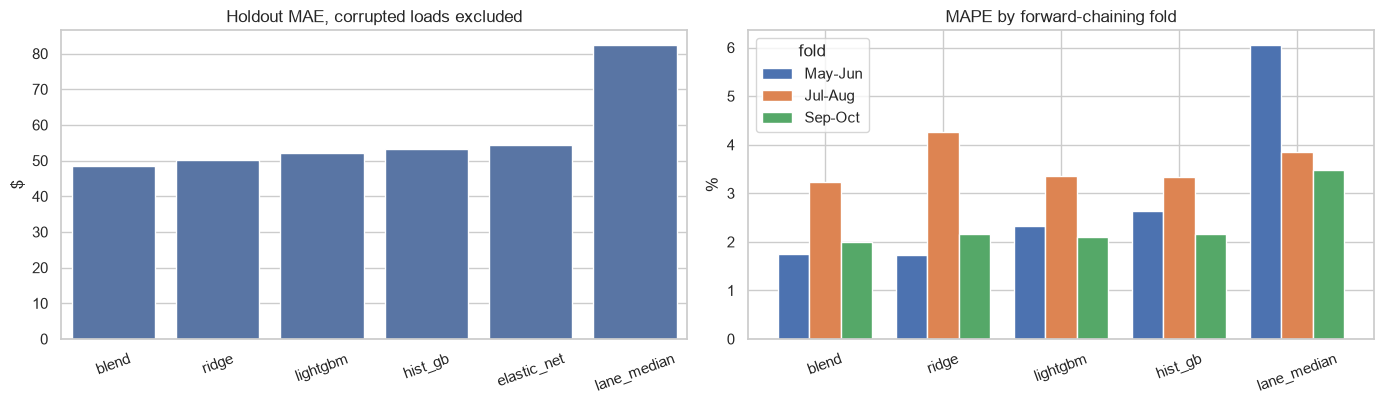

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
order = holdout.sort_values("mae_clean").model
sns.barplot(data=holdout, x="model", y="mae_clean", order=order, ax=axes[0]); axes[0].set_title("Holdout MAE, corrupted loads excluded"); axes[0].set_ylabel("$"); axes[0].set_xlabel("")
mape.drop(columns="mean").reindex(order).dropna().plot.bar(ax=axes[1], width=0.8); axes[1].set_title("MAPE by forward-chaining fold"); axes[1].set_ylabel("%"); axes[1].set_xlabel("")
for ax in axes: ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150); plt.show()

Observations:

- The **lane-median baseline** is hard to beat on lanes it has seen, but it has no notion of time, market conditions, or unseen lanes, and it is the worst model in every window.
- **Ridge on log rate** captures the multiplicative structure almost completely. Its residual spread is the tightest of any single model; where it loses is level, not shape. On the Jul-Aug window, trained on January to June only, the trend and the market index are nearly collinear and Ridge attributes too much of the spring rise to the index. With more history the two separate and the bias disappears.
- **Gradient boosting** (`hist_gb`, `lightgbm`) is slightly better on the tails and on the U-shaped `quote_signal` effect, but it cannot extrapolate the time trend beyond the last training day, so it under-predicts when rates keep rising.
- The **blend** averages Ridge and LightGBM in log space. Their errors are only partly correlated, so the blend beats both members in every window and is the final model.

## 2. Residual analysis on the primary holdout

In [5]:
raw = load_raw(TRAIN_PATH)
outlier = rate_outlier_mask(raw)
train_idx, valid_idx = time_holdout_split(raw)
train_rows = raw.iloc[train_idx]
train_rows = train_rows.loc[~outlier.iloc[train_idx].to_numpy()]
cleaner = Cleaner().fit(train_rows)
train_clean = cleaner.transform(train_rows)
valid_clean = cleaner.transform(raw.iloc[valid_idx])
keep = ~outlier.iloc[valid_idx].to_numpy()

X_train, y_train = build_features(train_clean), train_clean[TARGET].to_numpy()
X_valid, y_valid = build_features(valid_clean), valid_clean[TARGET].to_numpy()
fitted = {name: make_model(name).fit(X_train, y_train) for name in ("ridge", "lightgbm", "blend")}
predictions = {name: model.predict(X_valid) for name, model in fitted.items()}
pd.DataFrame({name: regression_metrics(y_valid[keep], pred[keep]) for name, pred in predictions.items()}).T.round(3)

,mae,rmse,mape,median_ape,r2
ridge,50.269,74.844,2.163,1.808,0.997
lightgbm,52.150,78.289,2.092,1.813,0.997
blend,48.445,72.920,2.006,1.686,0.997


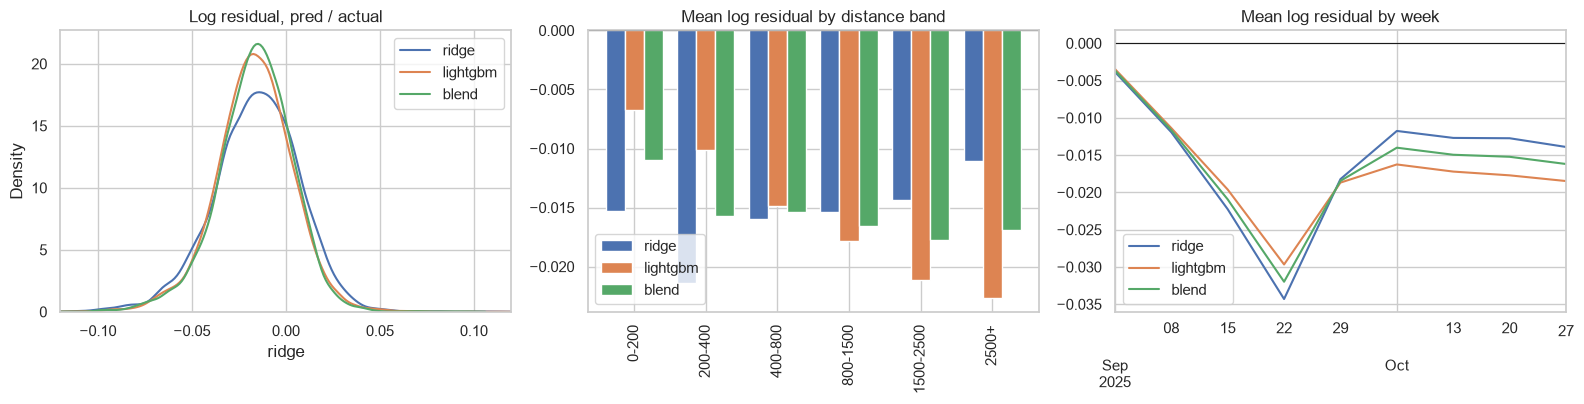

bias (mean log residual): {'ridge': -0.0157, 'lightgbm': -0.0168, 'blend': -0.0163}
spread (std log residual): {'ridge': 0.0233, 'lightgbm': 0.0206, 'blend': 0.0201}


In [6]:
residuals = pd.DataFrame({name: np.log(pred / y_valid) for name, pred in predictions.items()}, index=valid_clean.index)[keep]
context = valid_clean.loc[residuals.index]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name in residuals: sns.kdeplot(residuals[name], ax=axes[0], label=name)
axes[0].set_xlim(-0.12, 0.12); axes[0].set_title("Log residual, pred / actual"); axes[0].legend()
band_labels = ["0-200", "200-400", "400-800", "800-1500", "1500-2500", "2500+"]
residuals.groupby(distance_band(context.distance).to_numpy()).mean().set_axis(band_labels).plot.bar(ax=axes[1], width=0.8); axes[1].set_title("Mean log residual by distance band"); axes[1].axhline(0, color="k", lw=0.8)
residuals.groupby(context.date.dt.to_period("W").dt.start_time.to_numpy()).mean().plot(ax=axes[2]); axes[2].set_title("Mean log residual by week"); axes[2].axhline(0, color="k", lw=0.8); axes[2].set_xlabel("")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "residuals.png", dpi=150); plt.show()
print("bias (mean log residual):", residuals.mean().round(4).to_dict())
print("spread (std log residual):", residuals.std().round(4).to_dict())

In [7]:
seen_lanes = set(train_clean.pickup + ">" + train_clean.delivery)
seen = (context.pickup + ">" + context.delivery).isin(seen_lanes)
ape = (np.exp(residuals) - 1).abs() * 100
pd.DataFrame({
    "seen lane": ape[seen.to_numpy()].mean(),
    "unseen lane": ape[~seen.to_numpy()].mean(),
    "Dry Van": ape[(context.equipment == "Dry Van").to_numpy()].mean(),
    "Reefer": ape[(context.equipment == "Reefer").to_numpy()].mean(),
    "Flatbed": ape[(context.equipment == "Flatbed").to_numpy()].mean(),
}).round(2).rename_axis("MAPE %")

,seen lane,unseen lane,Dry Van,Reefer,Flatbed
MAPE %,,,,,
ridge,2.16,1.93,1.94,2.22,2.74
lightgbm,2.09,2.18,1.93,2.05,2.63
blend,2.01,1.98,1.83,1.98,2.56


Residuals are centred and symmetric with no structure left across distance bands or weeks. Unseen lanes are predicted as well as seen ones, which is the property the validation set needs given a third of its lanes are new.

## 3. What the models learned

In [8]:
ridge = fitted["ridge"].regressor_
prep, linear = ridge.named_steps["prep"], ridge.named_steps["model"]
names = prep.get_feature_names_out()
coef = pd.Series(linear.coef_, index=names)
numeric = coef[[n for n in names if n.startswith("numeric__")]].rename(lambda s: s.replace("numeric__", ""))
print("standardised numeric effects on log rate:")
print(numeric.round(4).sort_values().to_string())
print()
equipment = coef[[n for n in names if "equipment_" in n]].rename(lambda s: s.split("_")[-1])
print("equipment multipliers relative to mean:", np.exp(equipment - equipment.mean()).round(3).to_dict())

standardised numeric effects on log rate:
pickup_lat             -0.0151
delivery_lat           -0.0148
day_of_week            -0.0036
circuity               -0.0022
delta_lon              -0.0001
market_index_missing    0.0000
weight_missing          0.0001
delta_lat               0.0001
delivery_lon            0.0012
pickup_lon              0.0013
is_weekend              0.0051
quote_signal            0.0054
log_market_index        0.0061
haversine               0.0080
days_since_origin       0.0118
market_index            0.0209
weight                  0.0235
distance                0.4849

equipment multipliers relative to mean: {'Dry Van': 0.936, 'Flatbed': 1.012, 'Reefer': 1.056}


In [9]:
scale = prep.named_transformers_["numeric"].scale_
scaled_names = [c for c in NUMERIC_FEATURES if c != "log_distance"]
per_unit = numeric / pd.Series(scale, index=scaled_names)
mean_index = X_train["market_index"].mean()
elasticity = per_unit["log_market_index"] + per_unit["market_index"] * mean_index
print(f"time trend: {per_unit['days_since_origin'] * 30 * 100:.2f}% per month")
print(f"market index elasticity at the mean index: {elasticity:.3f}")
print(f"weight effect across the observed range: {per_unit['weight'] * (X_train['weight'].max() - X_train['weight'].min()) * 100:.1f}%")

time trend: 0.51% per month
market index elasticity at the mean index: 0.188
weight effect across the observed range: 12.6%


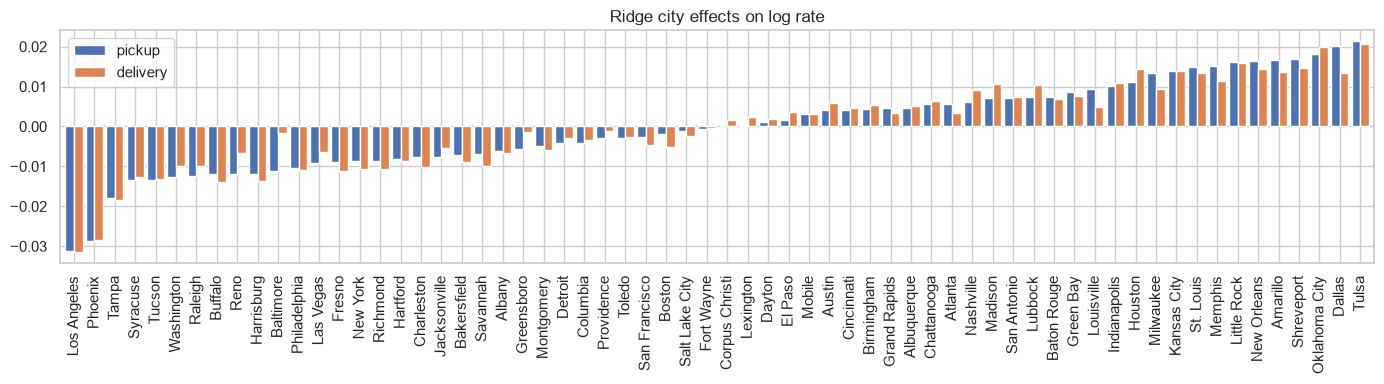

In [10]:
city = coef[[n for n in names if "categorical__pickup_" in n or "categorical__delivery_" in n]]
city_table = pd.DataFrame({
    "pickup": city[[n for n in city.index if "pickup_" in n]].rename(lambda s: s.split("pickup_")[-1]),
    "delivery": city[[n for n in city.index if "delivery_" in n]].rename(lambda s: s.split("delivery_")[-1]),
})
fig, ax = plt.subplots(figsize=(14, 4))
city_table.sort_values("pickup").plot.bar(ax=ax, width=0.85); ax.set_title("Ridge city effects on log rate"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

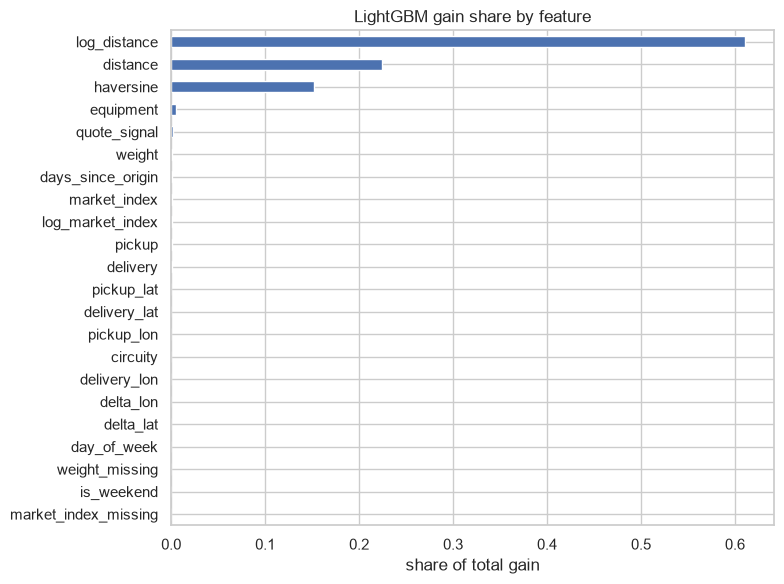

In [11]:
booster = fitted["lightgbm"].regressor_.named_steps["model"]
importance = pd.Series(booster.booster_.feature_importance("gain"), index=booster.feature_name_).sort_values()
importance = importance / importance.sum()
fig, ax = plt.subplots(figsize=(8, 6))
importance.rename(lambda s: s.split("__")[-1]).plot.barh(ax=ax); ax.set_title("LightGBM gain share by feature"); ax.set_xlabel("share of total gain")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150); plt.show()

Both models agree on the story: distance dominates, equipment and the origin and destination cities set the level, and the market index and time trend move everything together. The Ridge coefficients recover the 0.5% per month trend seen in the EDA and a market elasticity of the same order, which is a good sign that the linear structure is right rather than an artefact of regularisation.

## 4. Completing the fixed-lane December inputs

In [12]:
december = pd.read_csv(DECEMBER_PATH).drop(columns=["predicted_rate"]).assign(predicted_rate=np.nan)
completed = build_december_frame(december, raw, load_raw(VALIDATION_PATH))
completed[["date", "pickup", "delivery", "pickup_lat", "delivery_lat", "market_index", "quote_signal"]].head(7)

,date,pickup,delivery,pickup_lat,delivery_lat,market_index,quote_signal
0,2025-12-01,Lexington,Fort Wayne,36.99152,41.31561,0.834919,2.046565
1,2025-12-02,Lexington,Fort Wayne,36.99152,41.31561,0.914680,2.046565
2,2025-12-03,Lexington,Fort Wayne,36.99152,41.31561,0.994063,2.046565
3,2025-12-04,Lexington,Fort Wayne,36.99152,41.31561,1.024021,2.046565
4,2025-12-05,Lexington,Fort Wayne,36.99152,41.31561,0.975120,2.046565
5,2025-12-06,Lexington,Fort Wayne,36.99152,41.31561,0.889154,2.046565
6,2025-12-07,Lexington,Fort Wayne,36.99152,41.31561,0.830590,2.046565


The December rows carry only the five fixed inputs and a date. The model also expects coordinates, a market index, and a quote signal, so these are filled from the data already available: coordinates from the city reference, the market index from the same-day mean across the December loads in the validation set, and the quote signal from the training median for Dry Van. Only the date-driven inputs vary across the 31 rows, so the resulting chart isolates the day-of-week, market, and trend effects on one lane.

## 5. Final choice

The submitted model is the Ridge and LightGBM blend, refitted on all ten months with corrupted rates excluded. On the two-month forward holdout it reaches a MAPE of about 2.0% with the corrupted loads excluded and about 4.5% including them; the latter is the figure to expect against the true validation labels if they carry the same defect rate.